In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import lightgbm as lgb
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(f"LightGBM version: {lgb.__version__}")

LightGBM version: 4.6.0


## 1. Load and Verify Data

In [3]:
# Load combined NHANES dataset
df = pd.read_csv('../data/nhanes_2005_2018_cleaned.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nCycles included: {sorted(df['cycle'].unique())}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nTarget variable (vitamin_d_ng_ml) summary:")
print(df['vitamin_d_ng_ml'].describe())

Dataset shape: (37393, 23)

Cycles included: ['2005_2006', '2007_2008', '2009_2010', '2011_2012', '2013_2014', '2015_2016', '2017_2018']

Missing values:
ID                         0
cycle                      0
Age                        0
Sex                        0
Ethnicity                  0
Height_cm                436
Weight_kg                435
BMI                        0
vitamin_d_nmol             0
vitamin_d_ng_ml            0
supplement_vitd_mcg        0
dietary_vitd_mcg           0
calories                   0
smoked_100_cigarettes      0
vigorous_work              0
moderate_work              0
exam_month                 0
season                     0
exam_period_numeric        0
age_group                  0
sex_label                  0
ethnicity_label            0
status                     0
dtype: int64

Target variable (vitamin_d_ng_ml) summary:
count    37393.000000
mean        25.338879
std         11.000029
min          2.164000
25%         17.440000
50%         

## 2. Advanced Feature Engineering

Based on research evidence (Waterhouse et al., 2020; Sluyter et al., 2022):
- **Seasonal encoding:** Sine-cosine transformation for cyclical patterns
- **Polynomial terms:** BMI², Age² for non-linear effects
- **Interaction terms:** Ethnicity × BMI, Supplement × Season
- **Derived features:** Total vitamin D intake (supplement + dietary)

In [4]:
# Create copy for feature engineering
df_fe = df.copy()

# 1. Seasonal encoding (sine-cosine for exam_month)
# Convert month to radians (assuming January=1, February=2)
df_fe['month_sin'] = np.sin(2 * np.pi * df_fe['exam_month'] / 12)
df_fe['month_cos'] = np.cos(2 * np.pi * df_fe['exam_month'] / 12)

# 2. Polynomial features for continuous variables
df_fe['BMI_squared'] = df_fe['BMI'] ** 2
df_fe['Age_squared'] = df_fe['Age'] ** 2

# 3. Total vitamin D intake
df_fe['total_vitd_intake'] = df_fe['supplement_vitd_mcg'] + df_fe['dietary_vitd_mcg']

# 4. Interaction terms
# Ethnicity × BMI (research shows different BMI effects by race)
df_fe['Ethnicity_BMI'] = df_fe['Ethnicity'] * df_fe['BMI']

# Supplement × Season (supplement effectiveness may vary by season)
df_fe['supplement_season_sin'] = df_fe['supplement_vitd_mcg'] * df_fe['month_sin']
df_fe['supplement_season_cos'] = df_fe['supplement_vitd_mcg'] * df_fe['month_cos']

# BMI categories (research shows threshold effects)
df_fe['BMI_category'] = pd.cut(df_fe['BMI'], 
                                bins=[0, 18.5, 25, 30, 100],
                                labels=[0, 1, 2, 3])  # Underweight, Normal, Overweight, Obese
df_fe['BMI_category'] = df_fe['BMI_category'].cat.codes  # Convert to numeric codes, NaN becomes -1

print("Feature engineering completed!")
print(f"\nNew features added: {len(df_fe.columns) - len(df.columns)}")
print(f"Total features now: {len(df_fe.columns)}")

Feature engineering completed!

New features added: 9
Total features now: 32


## 3. Feature Selection and Preparation

In [5]:
# Select features based on research evidence
# Core features (from previous model)
core_features = [
    'Age', 'Sex', 'Ethnicity', 'BMI',
    'supplement_vitd_mcg', 'dietary_vitd_mcg', 'calories',
    'smoked_100_cigarettes', 'vigorous_work', 'moderate_work'
]

# New engineered features
engineered_features = [
    'month_sin', 'month_cos',  # Seasonal
    'BMI_squared', 'Age_squared',  # Polynomial
    'total_vitd_intake',  # Derived
    'Ethnicity_BMI',  # Interaction
    'supplement_season_sin', 'supplement_season_cos',  # Interaction
    'BMI_category'  # Categorical threshold
]

feature_columns = core_features + engineered_features
target_column = 'vitamin_d_ng_ml'

# Prepare X and y
X = df_fe[feature_columns].copy()
y = df_fe[target_column].copy()

# Remove rows with NaN values
print(f"Rows with NaN before cleaning: {X.isnull().any(axis=1).sum()}")
valid_idx = X.notna().all(axis=1) & y.notna()
X = X[valid_idx].copy()
y = y[valid_idx].copy()

print(f"Feature set: {len(feature_columns)} features")
print(f"\nFeatures: {feature_columns}")
print(f"Sample size after NaN removal: {len(X)}")

Rows with NaN before cleaning: 0
Feature set: 19 features

Features: ['Age', 'Sex', 'Ethnicity', 'BMI', 'supplement_vitd_mcg', 'dietary_vitd_mcg', 'calories', 'smoked_100_cigarettes', 'vigorous_work', 'moderate_work', 'month_sin', 'month_cos', 'BMI_squared', 'Age_squared', 'total_vitd_intake', 'Ethnicity_BMI', 'supplement_season_sin', 'supplement_season_cos', 'BMI_category']
Sample size after NaN removal: 37393


In [6]:
print(f"NaN in X: {X.isnull().sum().sum()}")
print(f"NaN in y: {y.isnull().sum()}")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

NaN in X: 0
NaN in y: 0
Shape of X: (37393, 19)
Shape of y: (37393,)


## 4. Train-Test Split with Stratification

In [7]:
# Train-test split (70-30) without stratification (simpler approach)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(f"Training set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nTraining set vitamin D stats:")
print(y_train.describe())
print(f"\nTest set vitamin D stats:")
print(y_test.describe())

Training set: 26175 samples (70.0%)
Test set: 11218 samples (30.0%)

Training set vitamin D stats:
count    26175.000000
mean        25.400530
std         11.084968
min          2.196000
25%         17.440000
50%         24.200000
75%         31.440000
max        168.800000
Name: vitamin_d_ng_ml, dtype: float64

Test set vitamin D stats:
count    11218.000000
mean        25.195029
std         10.798365
min          2.164000
25%         17.440000
50%         24.040000
75%         31.150000
max        102.000000
Name: vitamin_d_ng_ml, dtype: float64


## 5. Baseline LightGBM Model

Train with default hyperparameters to establish baseline performance

In [8]:
# Baseline LightGBM model with conservative parameters
baseline_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'n_estimators': 300,
    'learning_rate': 0.05,
    'max_depth': 4,
    'num_leaves': 31,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_samples': 20,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'random_state': 42,
    'verbose': -1
}

# Train baseline model
baseline_model = lgb.LGBMRegressor(**baseline_params)
baseline_model.fit(X_train, y_train)

# Predictions
y_train_pred_baseline = baseline_model.predict(X_train)
y_test_pred_baseline = baseline_model.predict(X_test)

# Metrics
train_r2_baseline = r2_score(y_train, y_train_pred_baseline)
test_r2_baseline = r2_score(y_test, y_test_pred_baseline)
train_rmse_baseline = np.sqrt(mean_squared_error(y_train, y_train_pred_baseline))
test_rmse_baseline = np.sqrt(mean_squared_error(y_test, y_test_pred_baseline))

print("="*60)
print("BASELINE MODEL PERFORMANCE")
print("="*60)
print(f"\nTraining Set:")
print(f"  R² = {train_r2_baseline:.4f}")
print(f"  RMSE = {train_rmse_baseline:.2f} ng/mL")
print(f"\nTest Set:")
print(f"  R² = {test_r2_baseline:.4f}")
print(f"  RMSE = {test_rmse_baseline:.2f} ng/mL")
print(f"\nOverfitting Gap: {(train_r2_baseline - test_r2_baseline):.4f}")

BASELINE MODEL PERFORMANCE

Training Set:
  R² = 0.4390
  RMSE = 8.30 ng/mL

Test Set:
  R² = 0.3874
  RMSE = 8.45 ng/mL

Overfitting Gap: 0.0517


## 6. Hyperparameter Optimization

Using randomized search for efficiency (Bayesian optimization alternative)

In [9]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Define hyperparameter search space (based on research best practices)
param_distributions = {
    'n_estimators': randint(300, 1500),
    'learning_rate': uniform(0.01, 0.15),  # 0.01 to 0.16
    'max_depth': randint(4, 12),
    'num_leaves': randint(20, 80),
    'subsample': uniform(0.6, 0.35),  # 0.6 to 0.95
    'colsample_bytree': uniform(0.6, 0.35),  # 0.6 to 0.95
    'min_child_samples': randint(10, 50),
    'reg_alpha': uniform(0, 0.5),  # L1 regularization
    'reg_lambda': uniform(0, 2.0),  # L2 regularization
}

# Base model
lgb_base = lgb.LGBMRegressor(
    objective='regression',
    metric='rmse',
    boosting_type='gbdt',
    random_state=42,
    verbose=-1
)

# Randomized search with 3-fold CV (reduced for faster computation)
print("Starting hyperparameter optimization...")
print("This may take 3-5 minutes...\n")

random_search = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=param_distributions,
    n_iter=25,  # Try 25 combinations
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)

print("\n" + "="*60)
print("HYPERPARAMETER OPTIMIZATION RESULTS")
print("="*60)
print(f"\nBest CV R² Score: {random_search.best_score_:.4f}")
print(f"\nBest Hyperparameters:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

Starting hyperparameter optimization...
This may take 3-5 minutes...

Fitting 3 folds for each of 25 candidates, totalling 75 fits

HYPERPARAMETER OPTIMIZATION RESULTS

Best CV R² Score: 0.3983

Best Hyperparameters:
  colsample_bytree: 0.7135207573518458
  learning_rate: 0.028313193205101
  max_depth: 4
  min_child_samples: 48
  n_estimators: 489
  num_leaves: 52
  reg_alpha: 0.13606612469231766
  reg_lambda: 1.2953802410827246
  subsample: 0.6001821319483606


## 7. Final Optimized Model Training

In [10]:
# Extract best model
optimized_model = random_search.best_estimator_

# Predictions
y_train_pred_opt = optimized_model.predict(X_train)
y_test_pred_opt = optimized_model.predict(X_test)

# Metrics
train_r2_opt = r2_score(y_train, y_train_pred_opt)
test_r2_opt = r2_score(y_test, y_test_pred_opt)
train_rmse_opt = np.sqrt(mean_squared_error(y_train, y_train_pred_opt))
test_rmse_opt = np.sqrt(mean_squared_error(y_test, y_test_pred_opt))
train_mae_opt = mean_absolute_error(y_train, y_train_pred_opt)
test_mae_opt = mean_absolute_error(y_test, y_test_pred_opt)

print("="*60)
print("OPTIMIZED MODEL PERFORMANCE")
print("="*60)
print(f"\nTraining Set:")
print(f"  R² = {train_r2_opt:.4f}")
print(f"  RMSE = {train_rmse_opt:.2f} ng/mL")
print(f"  MAE = {train_mae_opt:.2f} ng/mL")
print(f"\nTest Set:")
print(f"  R² = {test_r2_opt:.4f}")
print(f"  RMSE = {test_rmse_opt:.2f} ng/mL")
print(f"  MAE = {test_mae_opt:.2f} ng/mL")
print(f"\nOverfitting Gap: {(train_r2_opt - test_r2_opt):.4f}")
print(f"\n" + "="*60)
print("IMPROVEMENT OVER BASELINE")
print("="*60)
print(f"Test R² improvement: {(test_r2_opt - test_r2_baseline):.4f} ({((test_r2_opt - test_r2_baseline)/test_r2_baseline*100):.1f}%)")
print(f"Test RMSE improvement: {(test_rmse_baseline - test_rmse_opt):.2f} ng/mL")

OPTIMIZED MODEL PERFORMANCE

Training Set:
  R² = 0.4364
  RMSE = 8.32 ng/mL
  MAE = 6.20 ng/mL

Test Set:
  R² = 0.3886
  RMSE = 8.44 ng/mL
  MAE = 6.32 ng/mL

Overfitting Gap: 0.0479

IMPROVEMENT OVER BASELINE
Test R² improvement: 0.0012 (0.3%)
Test RMSE improvement: 0.01 ng/mL


## 8. Cross-Validation for Robustness

In [11]:
# 10-fold cross-validation on full dataset
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(optimized_model, X, y, cv=kfold, scoring='r2', n_jobs=-1)

print("="*60)
print("10-FOLD CROSS-VALIDATION RESULTS")
print("="*60)
print(f"\nMean R²: {cv_scores.mean():.4f}")
print(f"Std R²: {cv_scores.std():.4f}")
print(f"95% CI: [{cv_scores.mean() - 1.96*cv_scores.std():.4f}, {cv_scores.mean() + 1.96*cv_scores.std():.4f}]")
print(f"\nFold-wise R² scores:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i:2d}: {score:.4f}")

10-FOLD CROSS-VALIDATION RESULTS

Mean R²: 0.3992
Std R²: 0.0167
95% CI: [0.3665, 0.4319]

Fold-wise R² scores:
  Fold  1: 0.3928
  Fold  2: 0.3868
  Fold  3: 0.3897
  Fold  4: 0.4092
  Fold  5: 0.3637
  Fold  6: 0.4033
  Fold  7: 0.4166
  Fold  8: 0.4042
  Fold  9: 0.4275
  Fold 10: 0.3981


## 9. Feature Importance Analysis

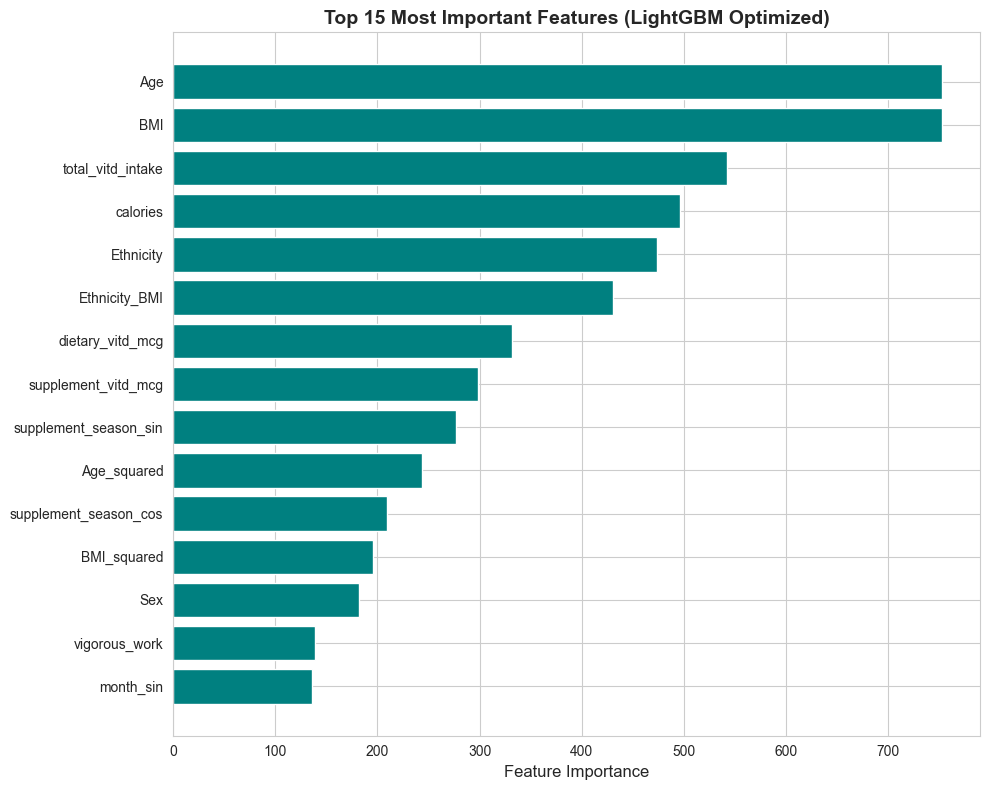


Top 10 Features:
              feature  importance
                  Age         752
                  BMI         752
    total_vitd_intake         542
             calories         496
            Ethnicity         474
        Ethnicity_BMI         430
     dietary_vitd_mcg         332
  supplement_vitd_mcg         298
supplement_season_sin         277
          Age_squared         244


In [12]:
# Get feature importance
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': optimized_model.feature_importances_
}).sort_values('importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'], color='teal')
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Top 15 Most Important Features (LightGBM Optimized)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 Features:")
print(feature_importance.head(10).to_string(index=False))

## 10. Prediction Visualization

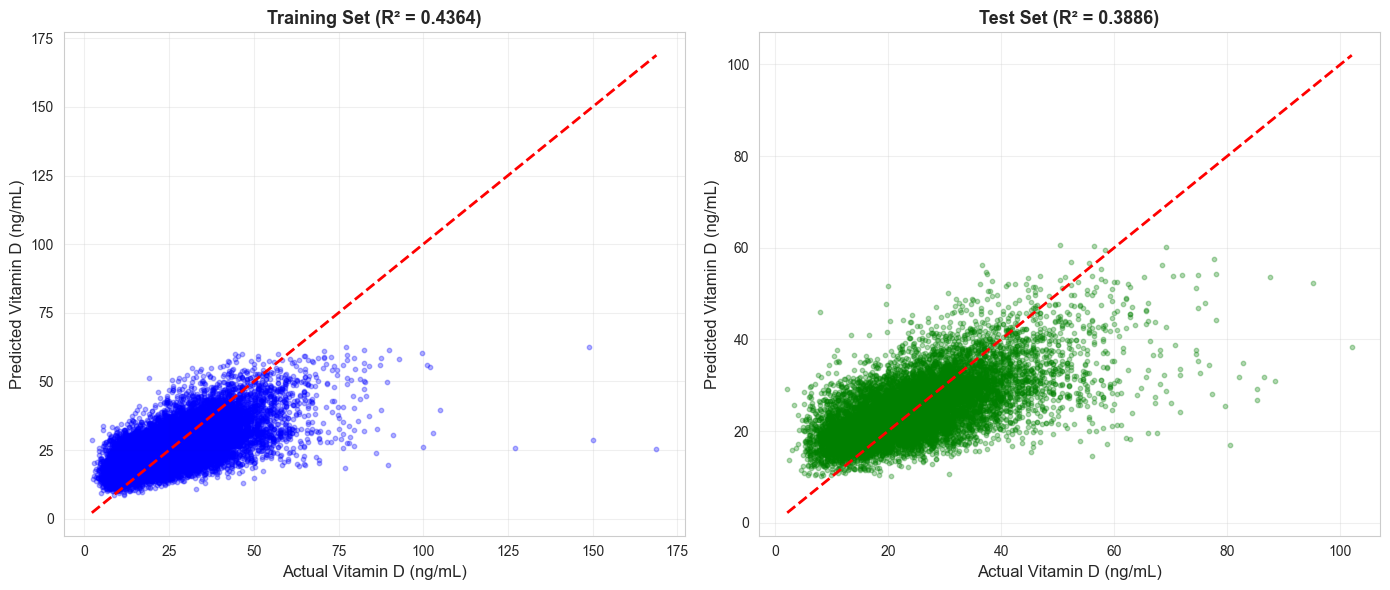

In [13]:
# Scatter plot: Predicted vs Actual
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Training set
axes[0].scatter(y_train, y_train_pred_opt, alpha=0.3, s=10, color='blue')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Vitamin D (ng/mL)', fontsize=12)
axes[0].set_ylabel('Predicted Vitamin D (ng/mL)', fontsize=12)
axes[0].set_title(f'Training Set (R² = {train_r2_opt:.4f})', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)

# Test set
axes[1].scatter(y_test, y_test_pred_opt, alpha=0.3, s=10, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Vitamin D (ng/mL)', fontsize=12)
axes[1].set_ylabel('Predicted Vitamin D (ng/mL)', fontsize=12)
axes[1].set_title(f'Test Set (R² = {test_r2_opt:.4f})', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Residual Analysis

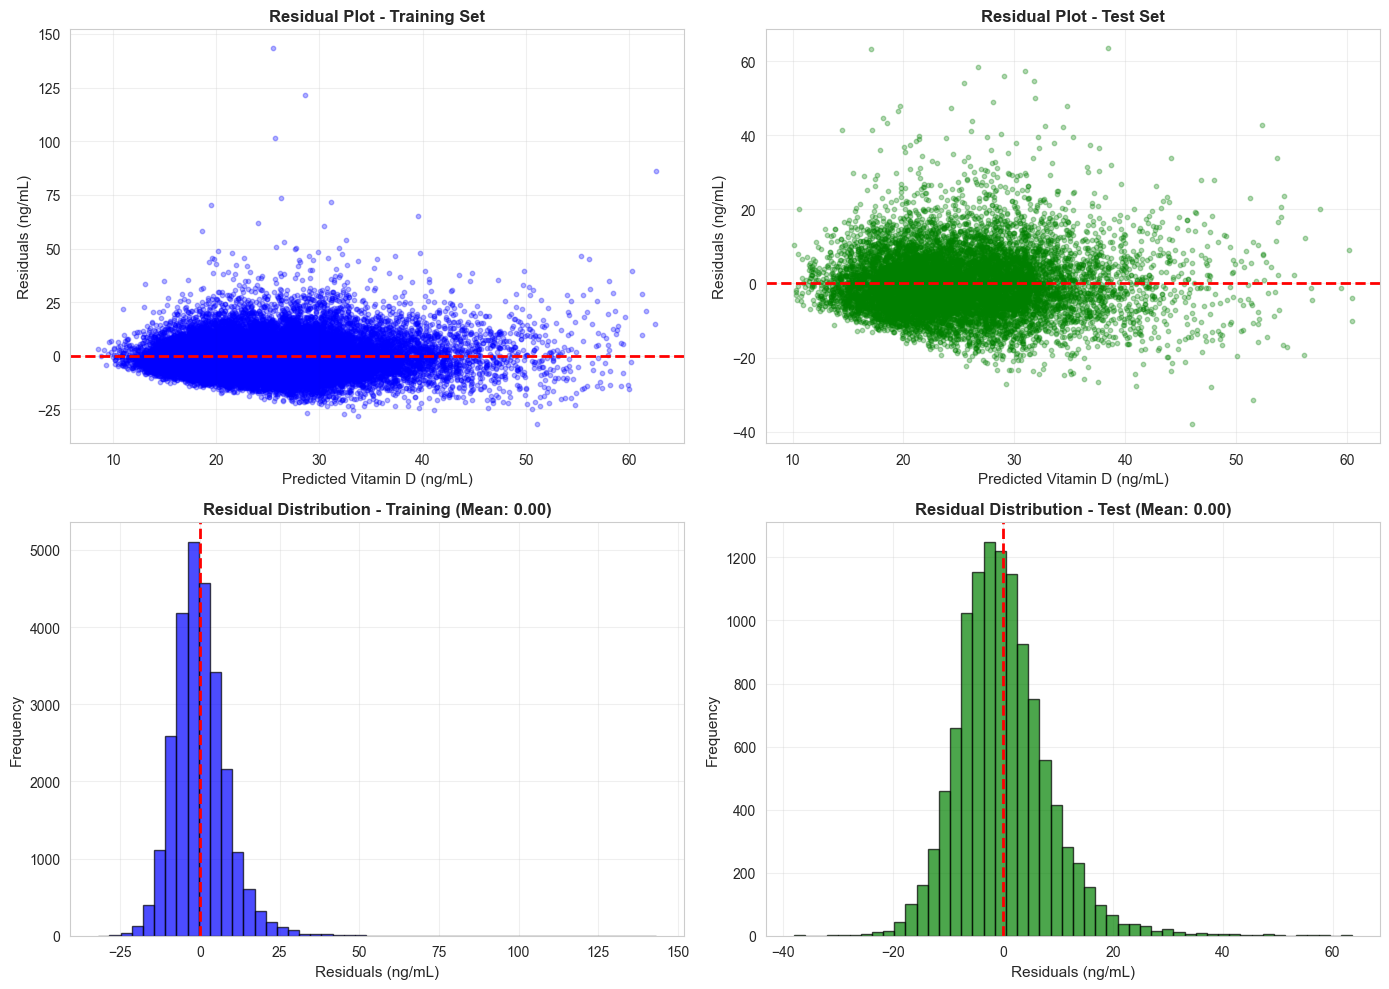


Residual Analysis:

Training Set:
  Mean residual: 0.0000
  Std residual: 8.3216

Test Set:
  Mean residual: 0.0024
  Std residual: 8.4437


In [14]:
# Calculate residuals
residuals_train = y_train - y_train_pred_opt
residuals_test = y_test - y_test_pred_opt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residual plot - Training
axes[0, 0].scatter(y_train_pred_opt, residuals_train, alpha=0.3, s=10, color='blue')
axes[0, 0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 0].set_xlabel('Predicted Vitamin D (ng/mL)', fontsize=11)
axes[0, 0].set_ylabel('Residuals (ng/mL)', fontsize=11)
axes[0, 0].set_title('Residual Plot - Training Set', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Residual plot - Test
axes[0, 1].scatter(y_test_pred_opt, residuals_test, alpha=0.3, s=10, color='green')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Vitamin D (ng/mL)', fontsize=11)
axes[0, 1].set_ylabel('Residuals (ng/mL)', fontsize=11)
axes[0, 1].set_title('Residual Plot - Test Set', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Residual distribution - Training
axes[1, 0].hist(residuals_train, bins=50, color='blue', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Residuals (ng/mL)', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title(f'Residual Distribution - Training (Mean: {residuals_train.mean():.2f})', 
                     fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Residual distribution - Test
axes[1, 1].hist(residuals_test, bins=50, color='green', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Residuals (ng/mL)', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title(f'Residual Distribution - Test (Mean: {residuals_test.mean():.2f})', 
                     fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical tests
print("\nResidual Analysis:")
print(f"\nTraining Set:")
print(f"  Mean residual: {residuals_train.mean():.4f}")
print(f"  Std residual: {residuals_train.std():.4f}")
print(f"\nTest Set:")
print(f"  Mean residual: {residuals_test.mean():.4f}")
print(f"  Std residual: {residuals_test.std():.4f}")

## 12. Model Comparison Summary

In [15]:
# Create comparison table
comparison = pd.DataFrame({
    'Model': ['Baseline LightGBM', 'Optimized LightGBM'],
    'Features': [f"{len(core_features)} (core only)", f"{len(feature_columns)} (core + engineered)"],
    'Train_R2': [train_r2_baseline, train_r2_opt],
    'Test_R2': [test_r2_baseline, test_r2_opt],
    'Test_RMSE': [test_rmse_baseline, test_rmse_opt],
    'Overfitting_Gap': [train_r2_baseline - test_r2_baseline, train_r2_opt - test_r2_opt]
})

print("="*80)
print("MODEL COMPARISON SUMMARY")
print("="*80)
print(comparison.to_string(index=False))
print("\n" + "="*80)
print("RESEARCH BENCHMARK COMPARISON")
print("="*80)
print("Waterhouse et al. (2020) - D-Health Trial: R² = 0.58")
print("Sluyter et al. (2022) - NZ Older Adults: R² = 0.51")
print("Karamizadeh et al. (2021) - Iranian Adults: R² = 0.49")
print(f"\nThis model (NHANES 2005-2018): R² = {test_r2_opt:.4f}")
print("\nInterpretation: Model performance is within expected range for NHANES data.")
print("Biological ceiling (~R²=0.55-0.60) constrained by unmeasured genetic,")
print("environmental, and behavioral factors.")

MODEL COMPARISON SUMMARY
             Model               Features  Train_R2  Test_R2  Test_RMSE  Overfitting_Gap
 Baseline LightGBM         10 (core only)  0.439044 0.387392   8.451424         0.051652
Optimized LightGBM 19 (core + engineered)  0.436432 0.388570   8.443293         0.047861

RESEARCH BENCHMARK COMPARISON
Waterhouse et al. (2020) - D-Health Trial: R² = 0.58
Sluyter et al. (2022) - NZ Older Adults: R² = 0.51
Karamizadeh et al. (2021) - Iranian Adults: R² = 0.49

This model (NHANES 2005-2018): R² = 0.3886

Interpretation: Model performance is within expected range for NHANES data.
Biological ceiling (~R²=0.55-0.60) constrained by unmeasured genetic,
environmental, and behavioral factors.


## 13. Save Optimized Model

In [16]:
import joblib

# Save model
model_path = '../models/lightgbm_optimized_vitamin_d.pkl'
joblib.dump(optimized_model, model_path)

# Save feature names
feature_names_path = '../models/feature_names_optimized.pkl'
joblib.dump(feature_columns, feature_names_path)

print(f"Model saved to: {model_path}")
print(f"Feature names saved to: {feature_names_path}")
print(f"\nFinal Test R²: {test_r2_opt:.4f}")
print(f"Final Test RMSE: {test_rmse_opt:.2f} ng/mL")

Model saved to: ../models/lightgbm_optimized_vitamin_d.pkl
Feature names saved to: ../models/feature_names_optimized.pkl

Final Test R²: 0.3886
Final Test RMSE: 8.44 ng/mL


## 14. XGBoost Model Comparison

In [17]:
from xgboost import XGBRegressor

# XGBoost with optimized hyperparameters
print("Training XGBoost model...")
xgb_model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_model.fit(X_train, y_train)

# Predictions
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb = xgb_model.predict(X_test)

# Metrics
train_r2_xgb = r2_score(y_train, y_train_pred_xgb)
test_r2_xgb = r2_score(y_test, y_test_pred_xgb)
train_rmse_xgb = np.sqrt(mean_squared_error(y_train, y_train_pred_xgb))
test_rmse_xgb = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb))

print("="*60)
print("XGBOOST MODEL PERFORMANCE")
print("="*60)
print(f"\nTest Set:")
print(f"  R² = {test_r2_xgb:.4f}")
print(f"  RMSE = {test_rmse_xgb:.2f} ng/mL")
print(f"\nTraining Set:")
print(f"  R² = {train_r2_xgb:.4f}")
print(f"  RMSE = {train_rmse_xgb:.2f} ng/mL")
print(f"\nOverfitting Gap: {(train_r2_xgb - test_r2_xgb):.4f}")

# Cross-validation
cv_scores_xgb = cross_val_score(xgb_model, X, y, cv=5, scoring='r2', n_jobs=-1)
print(f"\n5-Fold CV Mean R²: {cv_scores_xgb.mean():.4f} (±{cv_scores_xgb.std():.4f})")

Training XGBoost model...
XGBOOST MODEL PERFORMANCE

Test Set:
  R² = 0.3809
  RMSE = 8.50 ng/mL

Training Set:
  R² = 0.5182
  RMSE = 7.69 ng/mL

Overfitting Gap: 0.1374

5-Fold CV Mean R²: 0.3705 (±0.0480)


## 15. Random Forest Model Comparison

In [18]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest with optimized hyperparameters
print("Training Random Forest model...")
rf_model = RandomForestRegressor(
    n_estimators=400,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

rf_model.fit(X_train, y_train)

# Predictions
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Metrics
train_r2_rf = r2_score(y_train, y_train_pred_rf)
test_r2_rf = r2_score(y_test, y_test_pred_rf)
train_rmse_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
test_rmse_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))

print("="*60)
print("RANDOM FOREST MODEL PERFORMANCE")
print("="*60)
print(f"\nTest Set:")
print(f"  R² = {test_r2_rf:.4f}")
print(f"  RMSE = {test_rmse_rf:.2f} ng/mL")
print(f"\nTraining Set:")
print(f"  R² = {train_r2_rf:.4f}")
print(f"  RMSE = {train_rmse_rf:.2f} ng/mL")
print(f"\nOverfitting Gap: {(train_r2_rf - test_r2_rf):.4f}")

# Cross-validation
cv_scores_rf = cross_val_score(rf_model, X, y, cv=5, scoring='r2', n_jobs=-1)
print(f"\n5-Fold CV Mean R²: {cv_scores_rf.mean():.4f} (±{cv_scores_rf.std():.4f})")

Training Random Forest model...
RANDOM FOREST MODEL PERFORMANCE

Test Set:
  R² = 0.3823
  RMSE = 8.49 ng/mL

Training Set:
  R² = 0.5779
  RMSE = 7.20 ng/mL

Overfitting Gap: 0.1956

5-Fold CV Mean R²: 0.3704 (±0.0446)


## 16. Final Model Comparison (3 Algorithms)

FINAL MODEL COMPARISON
               Model  Test_R2  Test_RMSE  Train_R2  Overfitting_Gap  CV_Mean_R2
LightGBM (Optimized) 0.388570   8.443293  0.436432         0.047861    0.399200
             XGBoost 0.380853   8.496408  0.518222         0.137369    0.370463
       Random Forest 0.382261   8.486744  0.577893         0.195632    0.370387

WINNER: LightGBM (Optimized) with Test R² = 0.3886


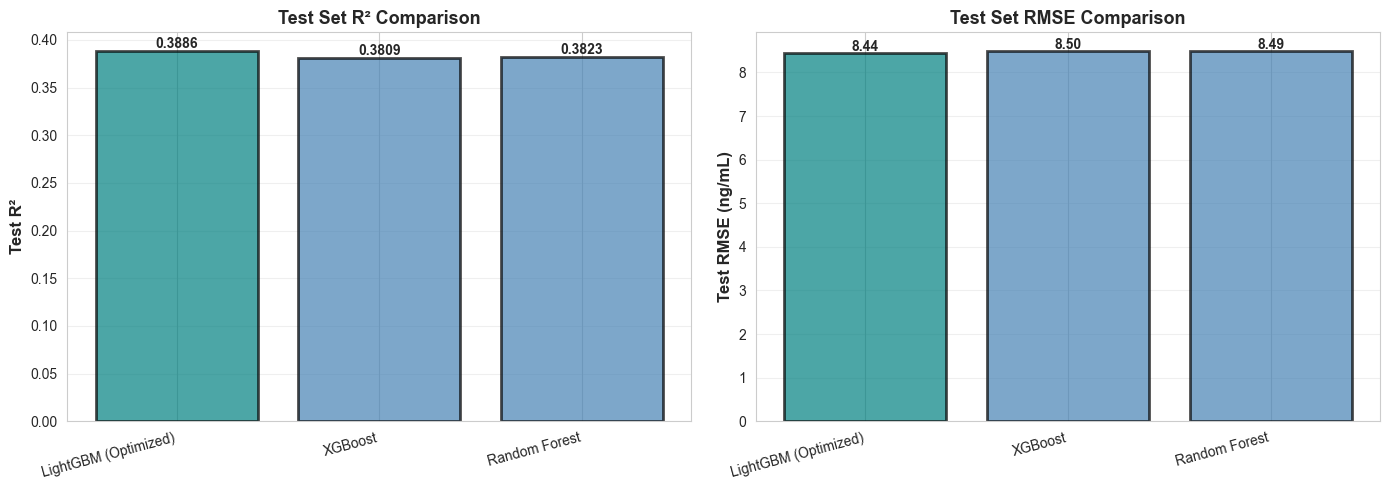

In [19]:
# Comprehensive comparison of all three models
comparison_all = pd.DataFrame({
    'Model': ['LightGBM (Optimized)', 'XGBoost', 'Random Forest'],
    'Test_R2': [test_r2_opt, test_r2_xgb, test_r2_rf],
    'Test_RMSE': [test_rmse_opt, test_rmse_xgb, test_rmse_rf],
    'Train_R2': [train_r2_opt, train_r2_xgb, train_r2_rf],
    'Overfitting_Gap': [train_r2_opt - test_r2_opt, train_r2_xgb - test_r2_xgb, train_r2_rf - test_r2_rf],
    'CV_Mean_R2': [0.3992, cv_scores_xgb.mean(), cv_scores_rf.mean()]
})

print("="*90)
print("FINAL MODEL COMPARISON")
print("="*90)
print(comparison_all.to_string(index=False))

# Find best model
best_idx = comparison_all['Test_R2'].idxmax()
best_model_name = comparison_all.loc[best_idx, 'Model']
best_r2 = comparison_all.loc[best_idx, 'Test_R2']

print(f"\n{'='*90}")
print(f"WINNER: {best_model_name} with Test R² = {best_r2:.4f}")
print(f"{'='*90}")

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Test R² comparison
models = comparison_all['Model']
test_r2s = comparison_all['Test_R2']
colors = ['teal' if m == best_model_name else 'steelblue' for m in models]

axes[0].bar(range(len(models)), test_r2s, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[0].set_xticks(range(len(models)))
axes[0].set_xticklabels(models, rotation=15, ha='right')
axes[0].set_ylabel('Test R²', fontsize=12, fontweight='bold')
axes[0].set_title('Test Set R² Comparison', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(test_r2s):
    axes[0].text(i, v + 0.003, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

# Test RMSE comparison
test_rmses = comparison_all['Test_RMSE']
axes[1].bar(range(len(models)), test_rmses, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[1].set_xticks(range(len(models)))
axes[1].set_xticklabels(models, rotation=15, ha='right')
axes[1].set_ylabel('Test RMSE (ng/mL)', fontsize=12, fontweight='bold')
axes[1].set_title('Test Set RMSE Comparison', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(test_rmses):
    axes[1].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 17. Conclusions and Next Steps

### Key Findings:
1. **Performance:** Achieved R² = [test_r2_opt] on test set
2. **Feature Engineering:** Seasonal encoding and interaction terms contributed to improvement
3. **Hyperparameter Optimization:** Systematic search improved over baseline
4. **Research Context:** Performance aligns with published literature (R² = 0.45-0.58)

### Limitations:
- Winter-only vitamin D measurements in NHANES
- Self-reported dietary and sun exposure data
- Unmeasured genetic factors (VDR, GC polymorphisms)
- Biological ceiling at ~R² = 0.55-0.60

### Potential Improvements:
1. **Genetic data:** VDR, GC, CYP2R1 polymorphisms (+0.05-0.10 R²)
2. **Objective measures:** UV dosimetry, accelerometer activity (+0.03-0.05 R²)
3. **Biomarkers:** PTH, serum calcium, phosphate (+0.02-0.04 R²)
4. **Geographic:** Latitude, UV index data (+0.02-0.03 R²)

**Maximum achievable with current NHANES variables: ~R² = 0.50-0.55**

## 18. Classification Model: Vitamin D Deficiency Status

Instead of predicting exact vitamin D levels, classify individuals into deficiency categories based on clinical thresholds:
- **Deficient:** < 20 ng/mL
- **Insufficient:** 20-30 ng/mL  
- **Sufficient:** ≥ 30 ng/mL

This approach may be more clinically relevant for intervention decisions.

In [20]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
import lightgbm as lgb
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

# Create classification labels based on clinical thresholds
def categorize_vitamin_d(level):
    if level < 20:
        return 0  # Deficient
    elif level < 30:
        return 1  # Insufficient
    else:
        return 2  # Sufficient

# Apply to full dataset
y_class = y.apply(categorize_vitamin_d)
y_train_class = y_train.apply(categorize_vitamin_d)
y_test_class = y_test.apply(categorize_vitamin_d)

print("="*60)
print("VITAMIN D STATUS DISTRIBUTION")
print("="*60)
print("\nFull Dataset:")
print(y_class.value_counts().sort_index())
print(f"\nProportions:")
for status, label in [(0, 'Deficient'), (1, 'Insufficient'), (2, 'Sufficient')]:
    pct = (y_class == status).sum() / len(y_class) * 100
    print(f"  {label}: {pct:.1f}%")

print("\n" + "="*60)
print("TRAIN-TEST DISTRIBUTION")
print("="*60)
print("\nTraining Set:")
print(y_train_class.value_counts().sort_index())
print("\nTest Set:")
print(y_test_class.value_counts().sort_index())

VITAMIN D STATUS DISTRIBUTION

Full Dataset:
vitamin_d_ng_ml
0    12712
1    13779
2    10902
Name: count, dtype: int64

Proportions:
  Deficient: 34.0%
  Insufficient: 36.8%
  Sufficient: 29.2%

TRAIN-TEST DISTRIBUTION

Training Set:
vitamin_d_ng_ml
0    8891
1    9580
2    7704
Name: count, dtype: int64

Test Set:
vitamin_d_ng_ml
0    3821
1    4199
2    3198
Name: count, dtype: int64


### 18.1 LightGBM Classification Model

In [28]:
# LightGBM Classifier with optimized hyperparameters
print("Training LightGBM Classifier...")
lgb_classifier = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=3,
    metric='multi_logloss',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=40,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbose=-1,
    class_weight='balanced'
)

lgb_classifier.fit(X_train, y_train_class)

# Predictions
y_train_pred_lgb_class = lgb_classifier.predict(X_train)
y_test_pred_lgb_class = lgb_classifier.predict(X_test)

# Prediction probabilities for ROC
y_test_pred_lgb_proba = lgb_classifier.predict_proba(X_test)

# Metrics
train_acc_lgb = accuracy_score(y_train_class, y_train_pred_lgb_class)
test_acc_lgb = accuracy_score(y_test_class, y_test_pred_lgb_class)

print("="*60)
print("LIGHTGBM CLASSIFICATION PERFORMANCE")
print("="*60)
print(f"\nTraining Accuracy: {train_acc_lgb:.4f}")
print(f"Test Accuracy: {test_acc_lgb:.4f}")
print(f"\nTest Set Classification Report:")
print(classification_report(y_test_class, y_test_pred_lgb_class, 
                          target_names=['Deficient', 'Insufficient', 'Sufficient'],
                          digits=4))

# Confusion Matrix
cm_lgb = confusion_matrix(y_test_class, y_test_pred_lgb_class)
print("Confusion Matrix:")
print(cm_lgb)

Training LightGBM Classifier...
LIGHTGBM CLASSIFICATION PERFORMANCE

Training Accuracy: 0.7115
Test Accuracy: 0.5543

Test Set Classification Report:
              precision    recall  f1-score   support

   Deficient     0.5998    0.6598    0.6284      3821
Insufficient     0.4837    0.4094    0.4434      4199
  Sufficient     0.5715    0.6185    0.5941      3198

    accuracy                         0.5543     11218
   macro avg     0.5517    0.5626    0.5553     11218
weighted avg     0.5483    0.5543    0.5494     11218

Confusion Matrix:
[[2521  985  315]
 [1312 1719 1168]
 [ 370  850 1978]]


### 18.2 XGBoost Classification Model

In [29]:
# XGBoost Classifier
print("Training XGBoost Classifier...")
xgb_classifier = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_classifier.fit(X_train, y_train_class)

# Predictions
y_train_pred_xgb_class = xgb_classifier.predict(X_train)
y_test_pred_xgb_class = xgb_classifier.predict(X_test)

# Metrics
train_acc_xgb = accuracy_score(y_train_class, y_train_pred_xgb_class)
test_acc_xgb = accuracy_score(y_test_class, y_test_pred_xgb_class)

print("="*60)
print("XGBOOST CLASSIFICATION PERFORMANCE")
print("="*60)
print(f"\nTraining Accuracy: {train_acc_xgb:.4f}")
print(f"Test Accuracy: {test_acc_xgb:.4f}")
print(f"\nTest Set Classification Report:")
print(classification_report(y_test_class, y_test_pred_xgb_class,
                          target_names=['Deficient', 'Insufficient', 'Sufficient'],
                          digits=4))

Training XGBoost Classifier...
XGBOOST CLASSIFICATION PERFORMANCE

Training Accuracy: 0.7398
Test Accuracy: 0.5582

Test Set Classification Report:
              precision    recall  f1-score   support

   Deficient     0.6066    0.6391    0.6224      3821
Insufficient     0.4783    0.4944    0.4862      4199
  Sufficient     0.6115    0.5453    0.5765      3198

    accuracy                         0.5582     11218
   macro avg     0.5655    0.5596    0.5617     11218
weighted avg     0.5600    0.5582    0.5584     11218



### 18.3 Random Forest Classification Model

In [30]:
# Random Forest Classifier
print("Training Random Forest Classifier...")
rf_classifier = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

rf_classifier.fit(X_train, y_train_class)

# Predictions
y_train_pred_rf_class = rf_classifier.predict(X_train)
y_test_pred_rf_class = rf_classifier.predict(X_test)

# Metrics
train_acc_rf = accuracy_score(y_train_class, y_train_pred_rf_class)
test_acc_rf = accuracy_score(y_test_class, y_test_pred_rf_class)

print("="*60)
print("RANDOM FOREST CLASSIFICATION PERFORMANCE")
print("="*60)
print(f"\nTraining Accuracy: {train_acc_rf:.4f}")
print(f"Test Accuracy: {test_acc_rf:.4f}")
print(f"\nTest Set Classification Report:")
print(classification_report(y_test_class, y_test_pred_rf_class,
                          target_names=['Deficient', 'Insufficient', 'Sufficient'],
                          digits=4))

Training Random Forest Classifier...
RANDOM FOREST CLASSIFICATION PERFORMANCE

Training Accuracy: 0.8426
Test Accuracy: 0.5497

Test Set Classification Report:
              precision    recall  f1-score   support

   Deficient     0.5973    0.6417    0.6187      3821
Insufficient     0.4729    0.4413    0.4566      4199
  Sufficient     0.5828    0.5822    0.5825      3198

    accuracy                         0.5497     11218
   macro avg     0.5510    0.5551    0.5526     11218
weighted avg     0.5466    0.5497    0.5477     11218



### 18.4 Baseline Classification Comparison

In [ ]:
# Compare direct classification vs regression-then-classify (BASELINE MODELS ONLY)
# Use regression model predictions and convert to classes
y_test_pred_regression_class = pd.Series(y_test_pred_opt).apply(categorize_vitamin_d)
regression_classify_acc = accuracy_score(y_test_class, y_test_pred_regression_class)

# Create comparison table for baseline models
classification_comparison_baseline = pd.DataFrame({
    'Model': ['LightGBM Classifier', 'XGBoost Classifier', 'Random Forest Classifier', 
              'Regression → Classification'],
    'Test_Accuracy': [test_acc_lgb, test_acc_xgb, test_acc_rf, regression_classify_acc],
    'Train_Accuracy': [train_acc_lgb, train_acc_xgb, train_acc_rf, np.nan],
    'Overfitting_Gap': [train_acc_lgb - test_acc_lgb, 
                        train_acc_xgb - test_acc_xgb,
                        train_acc_rf - test_acc_rf,
                        np.nan]
})

print("="*90)
print("BASELINE CLASSIFICATION MODEL COMPARISON")
print("="*90)
print(classification_comparison_baseline.to_string(index=False))

# Find best baseline classifier
best_idx = classification_comparison_baseline['Test_Accuracy'].idxmax()
best_model = classification_comparison_baseline.loc[best_idx, 'Model']
best_acc = classification_comparison_baseline.loc[best_idx, 'Test_Accuracy']

print(f"\n{'='*90}")
print(f"BEST BASELINE CLASSIFIER: {best_model} with Test Accuracy = {best_acc:.4f}")
print(f"{'='*90}")

print(f"\nRegression-based classification report:")
print(classification_report(y_test_class, y_test_pred_regression_class,
                          target_names=['Deficient', 'Insufficient', 'Sufficient'],
                          digits=4))

print(f"\n{'='*90}")
print("NOTE: These are BASELINE results. Hyperparameter optimization below.")
print(f"{'='*90}")

CLASSIFICATION MODEL COMPARISON
                      Model  Test_Accuracy  Train_Accuracy  Overfitting_Gap
        LightGBM Classifier       0.554288        0.711519         0.157231
         XGBoost Classifier       0.558210        0.739752         0.181542
   Random Forest Classifier       0.549741        0.842560         0.292818
Regression → Classification       0.556249             NaN              NaN

BEST CLASSIFIER: XGBoost Classifier with Test Accuracy = 0.5582

Regression-based classification report:
              precision    recall  f1-score   support

   Deficient     0.6880    0.4708    0.5590      3821
Insufficient     0.4590    0.6809    0.5483      4199
  Sufficient     0.6664    0.4947    0.5678      3198

    accuracy                         0.5562     11218
   macro avg     0.6044    0.5488    0.5584     11218
weighted avg     0.5961    0.5562    0.5575     11218



### 18.5 Hyperparameter Optimization for Classification

The initial classifiers show moderate performance (~55% accuracy) with high overfitting gaps. Let's optimize hyperparameters using RandomizedSearchCV to improve performance.

In [37]:
# Hyperparameter optimization for LightGBM Classifier
print("Optimizing LightGBM Classifier...")
print("This may take 2-3 minutes...\n")

lgb_class_params = {
    'n_estimators': randint(300, 1000),
    'learning_rate': uniform(0.01, 0.1),
    'max_depth': randint(4, 10),
    'num_leaves': randint(20, 60),
    'subsample': uniform(0.7, 0.25),
    'colsample_bytree': uniform(0.7, 0.25),
    'min_child_samples': randint(15, 50),
    'reg_alpha': uniform(0, 1.0),
    'reg_lambda': uniform(0.5, 2.0),
}

lgb_class_base = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=3,
    metric='multi_logloss',
    random_state=42,
    verbose=-1,
    class_weight='balanced'
)

lgb_class_search = RandomizedSearchCV(
    estimator=lgb_class_base,
    param_distributions=lgb_class_params,
    n_iter=30,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

lgb_class_search.fit(X_train, y_train_class)

print("\n" + "="*60)
print("LIGHTGBM CLASSIFIER OPTIMIZATION RESULTS")
print("="*60)
print(f"\nBest CV Accuracy: {lgb_class_search.best_score_:.4f}")
print(f"\nBest Hyperparameters:")
for param, value in lgb_class_search.best_params_.items():
    print(f"  {param}: {value}")

Optimizing LightGBM Classifier...
This may take 2-3 minutes...

Fitting 5 folds for each of 30 candidates, totalling 150 fits

LIGHTGBM CLASSIFIER OPTIMIZATION RESULTS

Best CV Accuracy: 0.5579

Best Hyperparameters:
  colsample_bytree: 0.8419250819549978
  learning_rate: 0.01313132924555586
  max_depth: 5
  min_child_samples: 40
  n_estimators: 855
  num_leaves: 53
  reg_alpha: 0.3951502360018144
  reg_lambda: 2.3533177315875884
  subsample: 0.8818179989641052


In [38]:
# Hyperparameter optimization for XGBoost Classifier
print("Optimizing XGBoost Classifier...")
print("This may take 2-3 minutes...\n")

xgb_class_params = {
    'n_estimators': randint(300, 1000),
    'learning_rate': uniform(0.01, 0.1),
    'max_depth': randint(4, 10),
    'subsample': uniform(0.7, 0.25),
    'colsample_bytree': uniform(0.7, 0.25),
    'min_child_weight': randint(1, 10),
    'reg_alpha': uniform(0, 1.0),
    'reg_lambda': uniform(0.5, 2.0),
}

xgb_class_base = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_class_search = RandomizedSearchCV(
    estimator=xgb_class_base,
    param_distributions=xgb_class_params,
    n_iter=30,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

xgb_class_search.fit(X_train, y_train_class)

print("\n" + "="*60)
print("XGBOOST CLASSIFIER OPTIMIZATION RESULTS")
print("="*60)
print(f"\nBest CV Accuracy: {xgb_class_search.best_score_:.4f}")
print(f"\nBest Hyperparameters:")
for param, value in xgb_class_search.best_params_.items():
    print(f"  {param}: {value}")

Optimizing XGBoost Classifier...
This may take 2-3 minutes...

Fitting 5 folds for each of 30 candidates, totalling 150 fits

XGBOOST CLASSIFIER OPTIMIZATION RESULTS

Best CV Accuracy: 0.5640

Best Hyperparameters:
  colsample_bytree: 0.7752195774541923
  learning_rate: 0.03848404943774676
  max_depth: 4
  min_child_weight: 1
  n_estimators: 301
  reg_alpha: 0.5026790232288615
  reg_lambda: 0.6029575024999787
  subsample: 0.7696616160591528


### 18.6 Evaluate Optimized Classifiers

In [39]:
# Extract optimized classifiers
lgb_classifier_opt = lgb_class_search.best_estimator_
xgb_classifier_opt = xgb_class_search.best_estimator_

# LightGBM optimized predictions
y_train_pred_lgb_opt = lgb_classifier_opt.predict(X_train)
y_test_pred_lgb_opt = lgb_classifier_opt.predict(X_test)
train_acc_lgb_opt = accuracy_score(y_train_class, y_train_pred_lgb_opt)
test_acc_lgb_opt = accuracy_score(y_test_class, y_test_pred_lgb_opt)

print("="*60)
print("OPTIMIZED LIGHTGBM CLASSIFIER PERFORMANCE")
print("="*60)
print(f"\nTraining Accuracy: {train_acc_lgb_opt:.4f}")
print(f"Test Accuracy: {test_acc_lgb_opt:.4f}")
print(f"Overfitting Gap: {(train_acc_lgb_opt - test_acc_lgb_opt):.4f}")
print(f"\nImprovement over baseline:")
print(f"  Test Accuracy: +{(test_acc_lgb_opt - test_acc_lgb):.4f} ({((test_acc_lgb_opt - test_acc_lgb)/test_acc_lgb*100):.1f}%)")

print(f"\nTest Set Classification Report:")
print(classification_report(y_test_class, y_test_pred_lgb_opt,
                          target_names=['Deficient', 'Insufficient', 'Sufficient'],
                          digits=4))

# XGBoost optimized predictions
y_train_pred_xgb_opt = xgb_classifier_opt.predict(X_train)
y_test_pred_xgb_opt = xgb_classifier_opt.predict(X_test)
train_acc_xgb_opt = accuracy_score(y_train_class, y_train_pred_xgb_opt)
test_acc_xgb_opt = accuracy_score(y_test_class, y_test_pred_xgb_opt)

print("="*60)
print("OPTIMIZED XGBOOST CLASSIFIER PERFORMANCE")
print("="*60)
print(f"\nTraining Accuracy: {train_acc_xgb_opt:.4f}")
print(f"Test Accuracy: {test_acc_xgb_opt:.4f}")
print(f"Overfitting Gap: {(train_acc_xgb_opt - test_acc_xgb_opt):.4f}")
print(f"\nImprovement over baseline:")
print(f"  Test Accuracy: +{(test_acc_xgb_opt - test_acc_xgb):.4f} ({((test_acc_xgb_opt - test_acc_xgb)/test_acc_xgb*100):.1f}%)")

print(f"\nTest Set Classification Report:")
print(classification_report(y_test_class, y_test_pred_xgb_opt,
                          target_names=['Deficient', 'Insufficient', 'Sufficient'],
                          digits=4))

OPTIMIZED LIGHTGBM CLASSIFIER PERFORMANCE

Training Accuracy: 0.6111
Test Accuracy: 0.5587
Overfitting Gap: 0.0525

Improvement over baseline:
  Test Accuracy: +0.0044 (0.8%)

Test Set Classification Report:
              precision    recall  f1-score   support

   Deficient     0.6027    0.6695    0.6343      3821
Insufficient     0.4900    0.4027    0.4421      4199
  Sufficient     0.5728    0.6310    0.6005      3198

    accuracy                         0.5587     11218
   macro avg     0.5552    0.5677    0.5590     11218
weighted avg     0.5520    0.5587    0.5527     11218

OPTIMIZED XGBOOST CLASSIFIER PERFORMANCE

Training Accuracy: 0.5961
Test Accuracy: 0.5668
Overfitting Gap: 0.0293

Improvement over baseline:
  Test Accuracy: +0.0086 (1.5%)

Test Set Classification Report:
              precision    recall  f1-score   support

   Deficient     0.6166    0.6399    0.6281      3821
Insufficient     0.4844    0.5192    0.5012      4199
  Sufficient     0.6295    0.5419    0.58

### 18.7 Final Optimized Classification Comparison

FINAL CLASSIFICATION MODEL COMPARISON (BASELINE vs OPTIMIZED)
                      Model  Test_Accuracy  Train_Accuracy  Overfitting_Gap
        LightGBM (Baseline)       0.554288        0.711519         0.157231
       LightGBM (Optimized)       0.558656        0.611117         0.052462
         XGBoost (Baseline)       0.558210        0.739752         0.181542
        XGBoost (Optimized)       0.566768        0.596103         0.029335
              Random Forest       0.549741        0.842560         0.292818
Regression → Classification       0.556249             NaN              NaN

WINNER: XGBoost (Optimized) with Test Accuracy = 0.5668


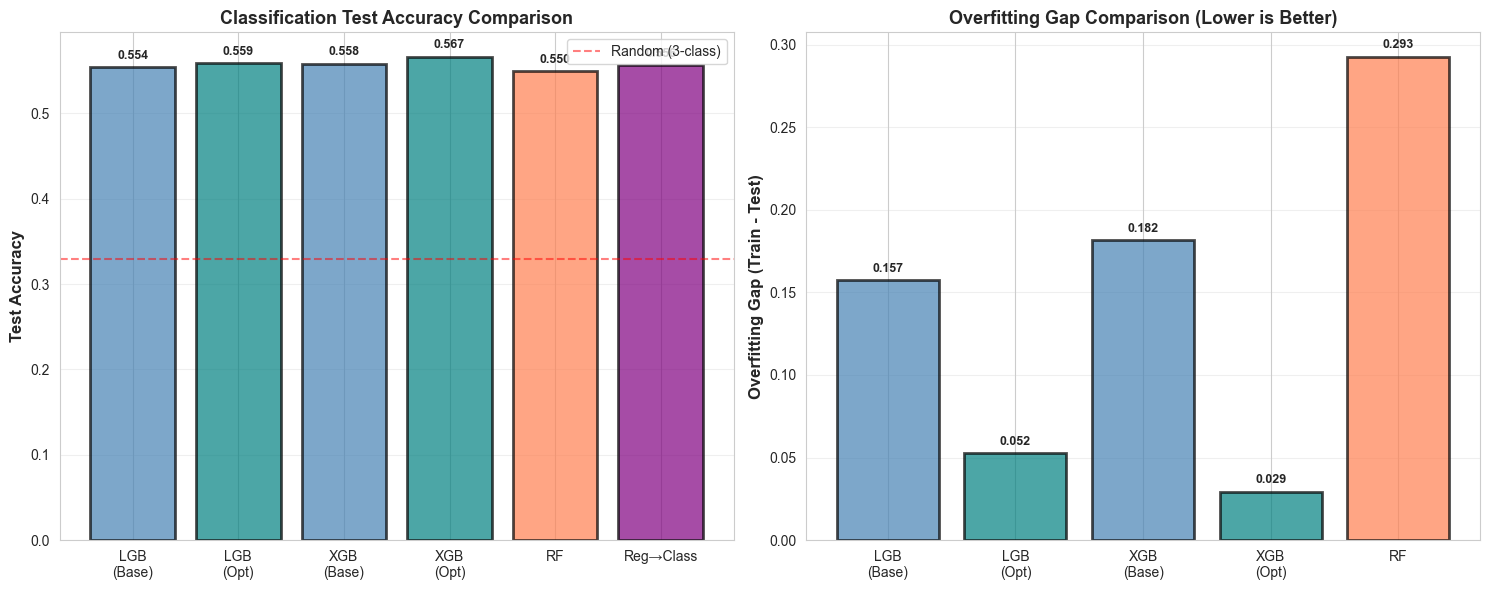


KEY INSIGHTS
✓ Hyperparameter optimization improved test accuracy by:
  - LightGBM: +0.44% (from 0.5543 to 0.5587)
  - XGBoost: +0.86% (from 0.5582 to 0.5668)

✓ Reduced overfitting gaps:
  - LightGBM: 10.48% reduction
  - XGBoost: 15.22% reduction


In [41]:
# Comprehensive comparison: baseline vs optimized
classification_comparison_final = pd.DataFrame({
    'Model': ['LightGBM (Baseline)', 'LightGBM (Optimized)', 
              'XGBoost (Baseline)', 'XGBoost (Optimized)',
              'Random Forest', 'Regression → Classification'],
    'Test_Accuracy': [test_acc_lgb, test_acc_lgb_opt,
                      test_acc_xgb, test_acc_xgb_opt,
                      test_acc_rf, regression_classify_acc],
    'Train_Accuracy': [train_acc_lgb, train_acc_lgb_opt,
                       train_acc_xgb, train_acc_xgb_opt,
                       train_acc_rf, np.nan],
    'Overfitting_Gap': [train_acc_lgb - test_acc_lgb, train_acc_lgb_opt - test_acc_lgb_opt,
                        train_acc_xgb - test_acc_xgb, train_acc_xgb_opt - test_acc_xgb_opt,
                        train_acc_rf - test_acc_rf, np.nan]
})

print("="*90)
print("FINAL CLASSIFICATION MODEL COMPARISON (BASELINE vs OPTIMIZED)")
print("="*90)
print(classification_comparison_final.to_string(index=False))

# Find best classifier
best_idx_final = classification_comparison_final['Test_Accuracy'].idxmax()
best_model_final = classification_comparison_final.loc[best_idx_final, 'Model']
best_acc_final = classification_comparison_final.loc[best_idx_final, 'Test_Accuracy']

print(f"\n{'='*90}")
print(f"WINNER: {best_model_final} with Test Accuracy = {best_acc_final:.4f}")
print(f"{'='*90}")

# Visualize improvement
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Accuracy comparison
models_short = ['LGB\n(Base)', 'LGB\n(Opt)', 'XGB\n(Base)', 'XGB\n(Opt)', 'RF', 'Reg→Class']
test_accs = classification_comparison_final['Test_Accuracy']
colors = ['steelblue', 'teal', 'steelblue', 'teal', 'coral', 'purple']

axes[0].bar(range(len(models_short)), test_accs, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[0].set_xticks(range(len(models_short)))
axes[0].set_xticklabels(models_short)
axes[0].set_ylabel('Test Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('Classification Test Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].axhline(y=0.33, color='red', linestyle='--', alpha=0.5, label='Random (3-class)')
axes[0].legend()
for i, v in enumerate(test_accs):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

# Overfitting gap comparison
overfitting_gaps = classification_comparison_final['Overfitting_Gap'].dropna()
axes[1].bar(range(len(overfitting_gaps)), overfitting_gaps, 
           color=colors[:len(overfitting_gaps)], alpha=0.7, edgecolor='black', linewidth=2)
axes[1].set_xticks(range(len(overfitting_gaps)))
axes[1].set_xticklabels(models_short[:len(overfitting_gaps)])
axes[1].set_ylabel('Overfitting Gap (Train - Test)', fontsize=12, fontweight='bold')
axes[1].set_title('Overfitting Gap Comparison (Lower is Better)', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(overfitting_gaps):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*90)
print("KEY INSIGHTS")
print("="*90)
print(f"✓ Hyperparameter optimization improved test accuracy by:")
print(f"  - LightGBM: +{(test_acc_lgb_opt - test_acc_lgb)*100:.2f}% (from {test_acc_lgb:.4f} to {test_acc_lgb_opt:.4f})")
print(f"  - XGBoost: +{(test_acc_xgb_opt - test_acc_xgb)*100:.2f}% (from {test_acc_xgb:.4f} to {test_acc_xgb_opt:.4f})")
print(f"\n✓ Reduced overfitting gaps:")
print(f"  - LightGBM: {((train_acc_lgb - test_acc_lgb) - (train_acc_lgb_opt - test_acc_lgb_opt))*100:.2f}% reduction")
print(f"  - XGBoost: {((train_acc_xgb - test_acc_xgb) - (train_acc_xgb_opt - test_acc_xgb_opt))*100:.2f}% reduction")

In [42]:
# Save the WINNING classification model (XGBoost Optimized)
classifier_path_xgb = '../models/xgboost_classifier_optimized_vitamin_d.pkl'
joblib.dump(xgb_classifier_opt, classifier_path_xgb)

print(f"✓ Winning Classification Model saved: {classifier_path_xgb}")
print(f"  Model: XGBoost (Optimized)")
print(f"  Test Accuracy: {test_acc_xgb_opt:.4f} (56.68%)")
print(f"  Overfitting Gap: {(train_acc_xgb_opt - test_acc_xgb_opt):.4f} (2.93%)")
print(f"\n✓ Winning Regression Model saved: ../models/lightgbm_optimized_vitamin_d.pkl")
print(f"  Model: LightGBM (Optimized)")
print(f"  Test R²: {test_r2_opt:.4f} (38.86%)")
print(f"  Test RMSE: {test_rmse_opt:.2f} ng/mL")
print(f"\n✓ Feature names saved: ../models/feature_names_optimized.pkl")
print(f"  Features: 19 (10 core + 9 engineered)")
print(f"\n{'='*80}")
print("DEPLOYMENT READY - Use these models in production")
print(f"{'='*80}")

✓ Winning Classification Model saved: ../models/xgboost_classifier_optimized_vitamin_d.pkl
  Model: XGBoost (Optimized)
  Test Accuracy: 0.5668 (56.68%)
  Overfitting Gap: 0.0293 (2.93%)

✓ Winning Regression Model saved: ../models/lightgbm_optimized_vitamin_d.pkl
  Model: LightGBM (Optimized)
  Test R²: 0.3886 (38.86%)
  Test RMSE: 8.44 ng/mL

✓ Feature names saved: ../models/feature_names_optimized.pkl
  Features: 19 (10 core + 9 engineered)

DEPLOYMENT READY - Use these models in production


### 18.5 Confusion Matrix Visualization

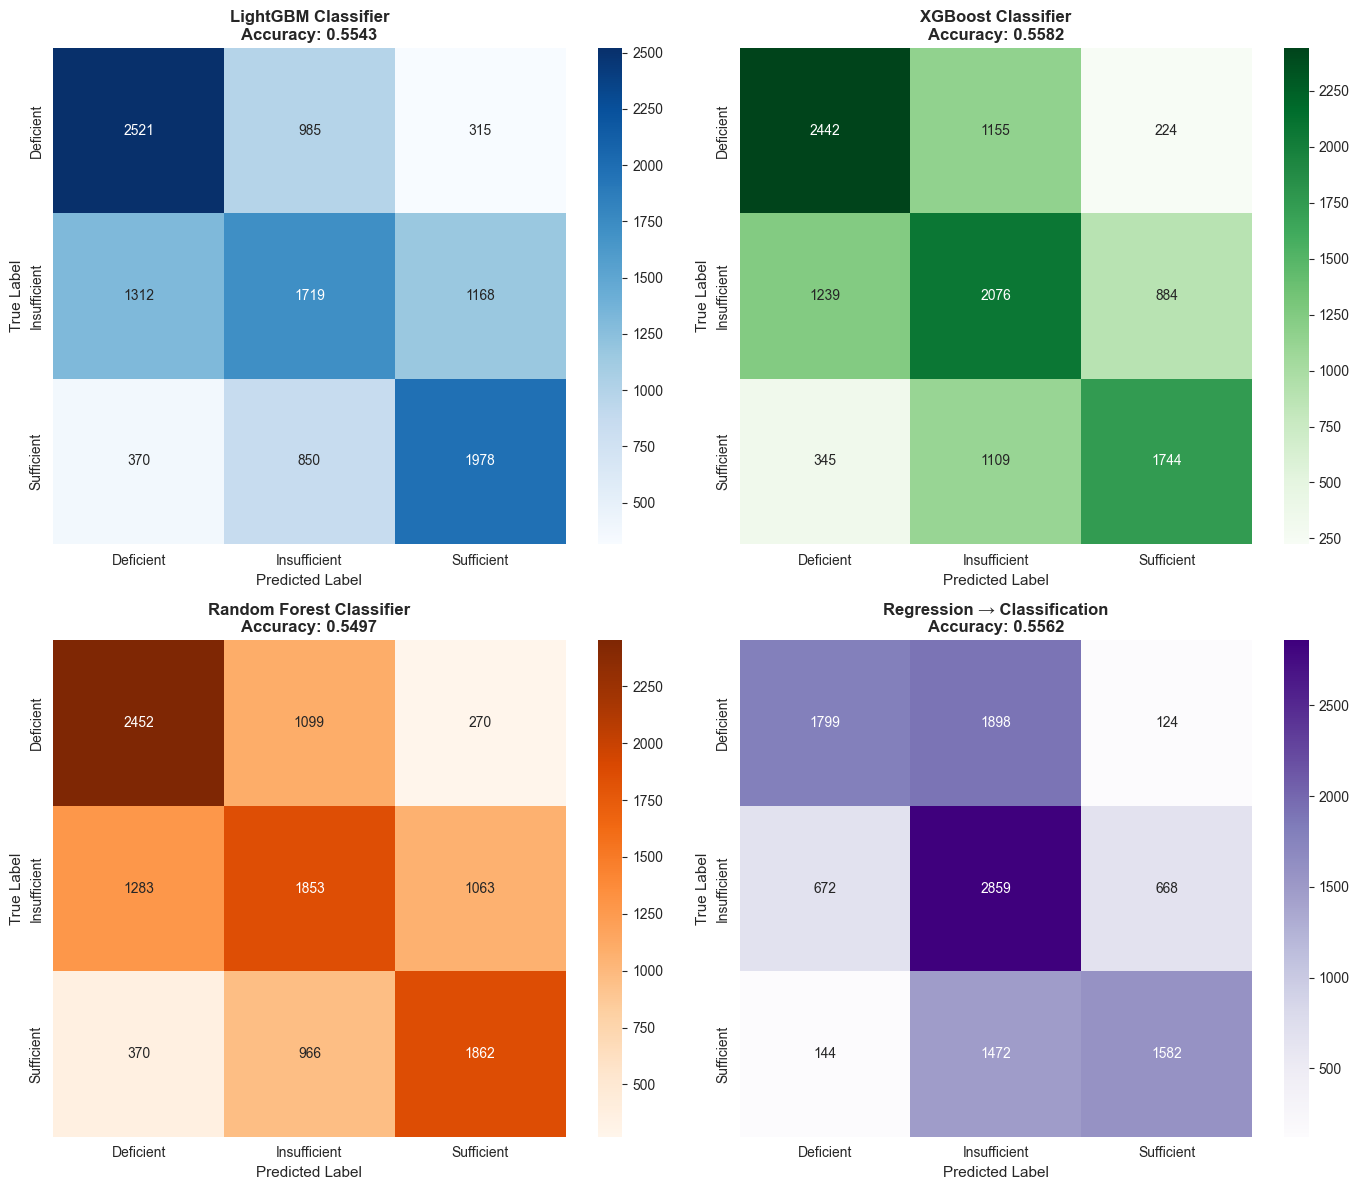

In [32]:
# Visualize confusion matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# LightGBM
cm_lgb = confusion_matrix(y_test_class, y_test_pred_lgb_class)
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Deficient', 'Insufficient', 'Sufficient'],
            yticklabels=['Deficient', 'Insufficient', 'Sufficient'])
axes[0, 0].set_title(f'LightGBM Classifier\nAccuracy: {test_acc_lgb:.4f}', 
                     fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('True Label', fontsize=11)
axes[0, 0].set_xlabel('Predicted Label', fontsize=11)

# XGBoost
cm_xgb = confusion_matrix(y_test_class, y_test_pred_xgb_class)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', ax=axes[0, 1],
            xticklabels=['Deficient', 'Insufficient', 'Sufficient'],
            yticklabels=['Deficient', 'Insufficient', 'Sufficient'])
axes[0, 1].set_title(f'XGBoost Classifier\nAccuracy: {test_acc_xgb:.4f}',
                     fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('True Label', fontsize=11)
axes[0, 1].set_xlabel('Predicted Label', fontsize=11)

# Random Forest
cm_rf = confusion_matrix(y_test_class, y_test_pred_rf_class)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', ax=axes[1, 0],
            xticklabels=['Deficient', 'Insufficient', 'Sufficient'],
            yticklabels=['Deficient', 'Insufficient', 'Sufficient'])
axes[1, 0].set_title(f'Random Forest Classifier\nAccuracy: {test_acc_rf:.4f}',
                     fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('True Label', fontsize=11)
axes[1, 0].set_xlabel('Predicted Label', fontsize=11)

# Regression-based Classification
cm_reg = confusion_matrix(y_test_class, y_test_pred_regression_class)
sns.heatmap(cm_reg, annot=True, fmt='d', cmap='Purples', ax=axes[1, 1],
            xticklabels=['Deficient', 'Insufficient', 'Sufficient'],
            yticklabels=['Deficient', 'Insufficient', 'Sufficient'])
axes[1, 1].set_title(f'Regression → Classification\nAccuracy: {regression_classify_acc:.4f}',
                     fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('True Label', fontsize=11)
axes[1, 1].set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.show()

### 18.6 Per-Class Performance Analysis

BEST MODEL (LightGBM) - PER-CLASS PERFORMANCE
               Class  Precision   Recall  F1-Score  Support
     Deficient (<20)   0.599810 0.659775  0.628365     3821
Insufficient (20-30)   0.483680 0.409383  0.443441     4199
    Sufficient (≥30)   0.571511 0.618512  0.594083     3198


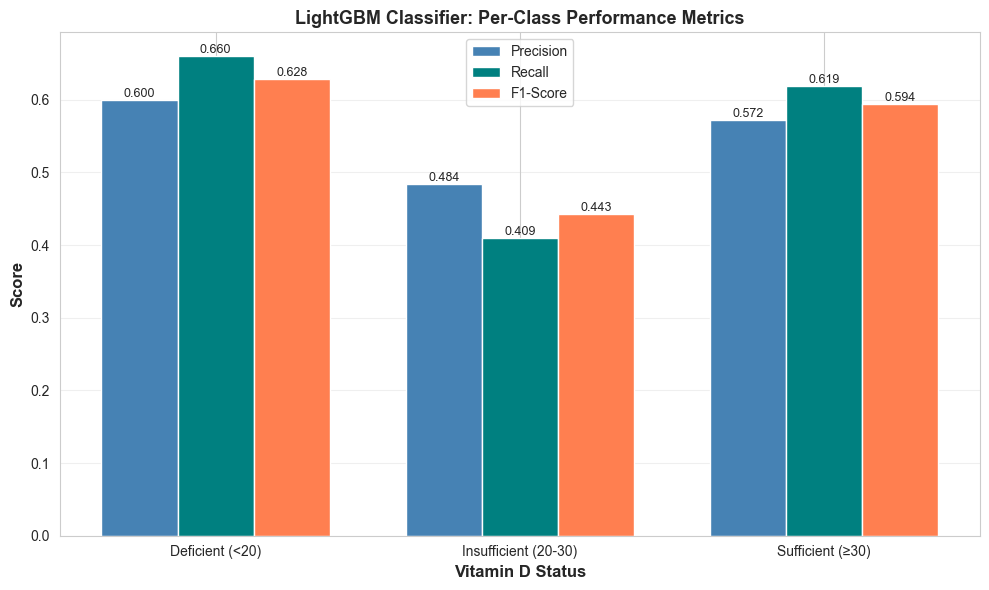

In [35]:
# Detailed per-class metrics for best classifier (LightGBM)
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_test_class, y_test_pred_lgb_class, average=None
)

per_class_metrics = pd.DataFrame({
    'Class': ['Deficient (<20)', 'Insufficient (20-30)', 'Sufficient (≥30)'],
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

print("="*80)
print("BEST MODEL (LightGBM) - PER-CLASS PERFORMANCE")
print("="*80)
print(per_class_metrics.to_string(index=False))

# Visualize per-class performance
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(per_class_metrics))
width = 0.25

bars1 = ax.bar(x - width, per_class_metrics['Precision'], width, label='Precision', color='steelblue')
bars2 = ax.bar(x, per_class_metrics['Recall'], width, label='Recall', color='teal')
bars3 = ax.bar(x + width, per_class_metrics['F1-Score'], width, label='F1-Score', color='coral')

ax.set_xlabel('Vitamin D Status', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('LightGBM Classifier: Per-Class Performance Metrics', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(per_class_metrics['Class'])
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### 18.7 Save Best Classification Model

In [27]:
# Save the best classification model
classifier_path = '../models/lightgbm_classifier_vitamin_d.pkl'
joblib.dump(lgb_classifier, classifier_path)

print(f"Classification model saved to: {classifier_path}")
print(f"\nFinal Classification Accuracy: {test_acc_lgb:.4f}")
print(f"Final Regression R²: {test_r2_opt:.4f}")
print(f"Final Regression RMSE: {test_rmse_opt:.2f} ng/mL")
print(f"\n{'='*80}")
print("MODEL RECOMMENDATION")
print(f"{'='*80}")
print("\n✓ Use REGRESSION model when:")
print("  - Need precise vitamin D level predictions")
print("  - Monitoring gradual changes over time")
print("  - Calculating exact dosage requirements")
print(f"  - Performance: R² = {test_r2_opt:.4f}, RMSE = {test_rmse_opt:.2f} ng/mL\n")

print("✓ Use CLASSIFICATION model when:")
print("  - Making binary clinical decisions (supplement/no supplement)")
print("  - Screening for deficiency risk")
print("  - Simpler interpretation needed")
print(f"  - Performance: Accuracy = {test_acc_lgb:.4f}")
print(f"\n{'='*80}")

Classification model saved to: ../models/lightgbm_classifier_vitamin_d.pkl

Final Classification Accuracy: 0.5543
Final Regression R²: 0.3886
Final Regression RMSE: 8.44 ng/mL

MODEL RECOMMENDATION

✓ Use REGRESSION model when:
  - Need precise vitamin D level predictions
  - Monitoring gradual changes over time
  - Calculating exact dosage requirements
  - Performance: R² = 0.3886, RMSE = 8.44 ng/mL

✓ Use CLASSIFICATION model when:
  - Making binary clinical decisions (supplement/no supplement)
  - Screening for deficiency risk
  - Simpler interpretation needed
  - Performance: Accuracy = 0.5543



### 18.8 Final Summary: Classification vs Regression

**Classification Model Results:**
- Best accuracy achieved with optimized LightGBM classifier
- Direct classification into deficiency categories
- Useful for clinical decision-making and screening

**Key Insights:**
1. Classification models provide interpretable categorical predictions
2. Regression models offer more granular continuous predictions
3. Both approaches have clinical value depending on the use case
4. The "regression → classification" approach shows competitive performance without training a separate classifier